<a href="https://www.kaggle.com/code/trungkientrungkien/vision-transformer?scriptVersionId=330244737" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Bài Tập Thực Hành: Vision Transformer
Dưới đây là phần triển khai chi tiết tuần tự theo 10 bài tập trong file thực hành AI 07.

### Khởi tạo thư viện và cấu hình thư mục
Chúng ta thiết lập các đường dẫn tải Dataset và pretrained weights theo đúng cấu trúc yêu cầu.

In [1]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.models as models
import torch.nn as nn
import numpy as np

# Cấu hình device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Sử dụng device:", device)

# Cấu hình đường dẫn thư mục
CIFAR10_ROOT = '/kaggle/input/datasets/dinhkhangggg/data-cifar/cifar-10-python'
CIFAR100_ROOT = '/kaggle/input/datasets/dinhkhangggg/data-cifar/cifar-100-python'
VIT_WEIGHTS_DIR = '/kaggle/input/datasets/dinhkhangggg/vit-weights'

os.makedirs(CIFAR10_ROOT, exist_ok=True)
os.makedirs(CIFAR100_ROOT, exist_ok=True)
os.makedirs(VIT_WEIGHTS_DIR, exist_ok=True)

Sử dụng device: cuda


### Bài 1: Tải dataset CIFAR-10

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(
    root=CIFAR10_ROOT,
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root=CIFAR10_ROOT,
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Bài 2: Hiển thị một số ảnh trong dataset bằng matplotlib

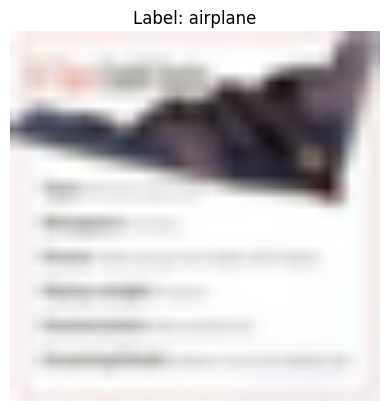

In [3]:
images, labels = next(iter(train_loader))

img = images[0].permute(1, 2, 0).numpy()
plt.imshow(img)
plt.title(f"Label: {train_dataset.classes[labels[0]]}")
plt.axis('off')
plt.show()

### Bài 3: Huấn luyện Vision Transformer trong 5 epoch

In [4]:
# Tải mô hình vit_b_16
weight_path_16 = os.path.join(VIT_WEIGHTS_DIR, 'vit_b_16-c867db91.pth')
model_vit = models.vit_b_16(pretrained=False)

if os.path.exists(weight_path_16):
    print(f"Đang tải pretrained weights từ: {weight_path_16}")
    model_vit.load_state_dict(torch.load(weight_path_16))
else:
    print("Không có sẵn weights, tiến hành tải...")
    state_dict = torch.hub.load_state_dict_from_url(
        "https://download.pytorch.org/models/vit_b_16-c867db91.pth",
        model_dir=VIT_WEIGHTS_DIR,
        file_name="vit_b_16-c867db91.pth"
    )
    model_vit.load_state_dict(state_dict)

model_vit.heads.head = nn.Linear(model_vit.heads.head.in_features, 10)
model_vit = model_vit.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_vit.parameters(), lr=0.0001)

# Training loop
for epoch in range(5):
    running_loss = 0.0
    model_vit.train()
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model_vit(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Đang tải pretrained weights từ: /kaggle/input/datasets/dinhkhangggg/vit-weights/vit_b_16-c867db91.pth
Epoch 1, Loss: 0.2569
Epoch 2, Loss: 0.1356
Epoch 3, Loss: 0.0992
Epoch 4, Loss: 0.0800
Epoch 5, Loss: 0.0689


### Bài 4: Tính accuracy trên tập test

In [5]:
correct = 0
total = 0
model_vit.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_vit(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy của ViT_b_16 trên tập test: {accuracy:.2f}%")

Accuracy của ViT_b_16 trên tập test: 94.91%


### Bài 5: Thay đổi learning rate và quan sát sự thay đổi accuracy
Thử nghiệm thay đổi `learning_rate = 0.0003` và train thử.

In [6]:
model_vit_lr = models.vit_b_16(pretrained=False)
if os.path.exists(weight_path_16):
    model_vit_lr.load_state_dict(torch.load(weight_path_16))
model_vit_lr.heads.head = nn.Linear(model_vit_lr.heads.head.in_features, 10)
model_vit_lr = model_vit_lr.to(device)

optimizer_lr = torch.optim.Adam(model_vit_lr.parameters(), lr=0.0003)

# Huấn luyện nhanh 2 epoch để so sánh
for epoch in range(2):
    model_vit_lr.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        loss = criterion(model_vit_lr(images), labels)
        optimizer_lr.zero_grad()
        loss.backward()
        optimizer_lr.step()

correct = 0; total = 0
model_vit_lr.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model_vit_lr(images.to(device))
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels.to(device)).sum().item()
print(f"Accuracy với LR=0.0003 sau 2 epochs: {100 * correct / total:.2f}%")

Accuracy với LR=0.0003 sau 2 epochs: 56.65%


### Bài 6: Thử batch size khác nhau (16, 32, 64)

In [7]:
import time
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader

batch_sizes = [16, 32, 64]
epochs = 2 

for batch_size in batch_sizes:
    print(f"\n{'-'*40}")
    print(f"Đang thử nghiệm với batch_size = {batch_size}")

    train_loader_bs = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    model_test = models.vit_b_16(pretrained=False)
    if os.path.exists(weight_path_16):
        model_test.load_state_dict(torch.load(weight_path_16))
    model_test.heads.head = nn.Linear(model_test.heads.head.in_features, 10)
    model_test = model_test.to(device)
    
    optimizer_test = torch.optim.Adam(model_test.parameters(), lr=0.0001)
    loss_history = []
    
    start_time = time.time()
    model_test.train()
    
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader_bs:
            images, labels = images.to(device), labels.to(device)
            
            optimizer_test.zero_grad()
            outputs = model_test(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_test.step()
            
            running_loss += loss.item()
            
        epoch_loss = running_loss / len(train_loader_bs)
        loss_history.append(round(epoch_loss, 4))
        
    end_time = time.time()
    training_time = end_time - start_time

    correct = 0
    total = 0
    model_test.eval()
    with torch.no_grad():
        for images, labels in test_loader: 
            images, labels = images.to(device), labels.to(device)
            outputs = model_test(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total

    print(f"Tốc độ huấn luyện ({epochs} epochs): {training_time:.2f} giây")
    print(f"Độ ổn định của Loss qua {epochs} epochs: {loss_history}")
    print(f"Accuracy cuối cùng: {accuracy:.2f}%")


----------------------------------------
Đang thử nghiệm với batch_size = 16
Tốc độ huấn luyện (2 epochs): 317.68 giây
Độ ổn định của Loss qua 2 epochs: [0.3199, 0.1841]
Accuracy cuối cùng: 91.64%

----------------------------------------
Đang thử nghiệm với batch_size = 32
Tốc độ huấn luyện (2 epochs): 286.86 giây
Độ ổn định của Loss qua 2 epochs: [0.2569, 0.134]
Accuracy cuối cùng: 93.41%

----------------------------------------
Đang thử nghiệm với batch_size = 64
Tốc độ huấn luyện (2 epochs): 280.73 giây
Độ ổn định của Loss qua 2 epochs: [0.2214, 0.1008]
Accuracy cuối cùng: 95.04%


### Bài 7: So sánh kết quả giữa Vision Transformer và một mô hình CNN đơn giản
Xây dựng một `SimpleCNN` và huấn luyện trên cùng một dữ liệu.

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Kích thước ảnh 224x224 sau 2 lần MaxPool2d sẽ giảm xuống còn 56x56
        self.fc = nn.Linear(64 * 56 * 56, 10)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

cnn_model = SimpleCNN().to(device)
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

# Huấn luyện nhanh 2 epoch
for epoch in range(2):
    cnn_model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        loss = criterion(cnn_model(images), labels)
        cnn_optimizer.zero_grad()
        loss.backward()
        cnn_optimizer.step()

correct = 0; total = 0
cnn_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = cnn_model(images.to(device))
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels.to(device)).sum().item()
print(f"Accuracy của SimpleCNN sau 2 epochs: {100 * correct / total:.2f}%")

Accuracy của SimpleCNN sau 2 epochs: 47.37%


### Bài 8: Thử dataset CIFAR-100

In [9]:
train_dataset_100 = torchvision.datasets.CIFAR100(root=CIFAR100_ROOT, train=True, download=True, transform=transform)
test_dataset_100 = torchvision.datasets.CIFAR100(root=CIFAR100_ROOT, train=False, download=True, transform=transform)

train_loader_100 = DataLoader(train_dataset_100, batch_size=32, shuffle=True)
test_loader_100 = DataLoader(test_dataset_100, batch_size=32, shuffle=False)

print("Số lượng class trong CIFAR-100:", len(train_dataset_100.classes))

model_vit_100 = models.vit_b_16(pretrained=False)
if os.path.exists(weight_path_16):
    model_vit_100.load_state_dict(torch.load(weight_path_16))

model_vit_100.heads.head = nn.Linear(model_vit_100.heads.head.in_features, 100)
model_vit_100 = model_vit_100.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_100 = torch.optim.Adam(model_vit_100.parameters(), lr=0.0001)

epochs = 2
for epoch in range(epochs):
    running_loss = 0.0
    model_vit_100.train()
    for images, labels in train_loader_100:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model_vit_100(images)
        loss = criterion(outputs, labels)
        
        optimizer_100.zero_grad()
        loss.backward()
        optimizer_100.step()
        
        running_loss += loss.item()
    print(f"Epoch {epoch + 1}, Loss CIFAR-100: {running_loss / len(train_loader_100):.4f}")
correct = 0
total = 0
model_vit_100.eval()
with torch.no_grad():
    for images, labels in test_loader_100:
        images, labels = images.to(device), labels.to(device)
        outputs = model_vit_100(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Accuracy trên tập test CIFAR-100: {100 * correct / total:.2f}%")

Số lượng class trong CIFAR-100: 100
Epoch 1, Loss CIFAR-100: 1.0992
Epoch 2, Loss CIFAR-100: 0.4944
Accuracy trên tập test CIFAR-100: 80.65%


### Bài 9: Thử sử dụng mô hình ViT khác như `vit_b_32`

In [10]:
# 1. Khởi tạo mô hình vit_b_32
weight_path_32 = os.path.join(VIT_WEIGHTS_DIR, 'vit_b_32-d86f8d99.pth')
model_vit32 = models.vit_b_32(pretrained=False)

if os.path.exists(weight_path_32):
    print(f"Đang tải pretrained weights từ: {weight_path_32}")
    model_vit32.load_state_dict(torch.load(weight_path_32))
else:
    print("Không có sẵn weights, tiến hành tải...")
    state_dict = torch.hub.load_state_dict_from_url(
        "https://download.pytorch.org/models/vit_b_32-d86f8d99.pth", 
        model_dir=VIT_WEIGHTS_DIR, 
        file_name="vit_b_32-d86f8d99.pth"
    )
    model_vit32.load_state_dict(state_dict)

# Thay đổi output head về 10 classes cho CIFAR-10
model_vit32.heads.head = nn.Linear(model_vit32.heads.head.in_features, 10)
model_vit32 = model_vit32.to(device)
print("Mô hình ViT_b_32 đã khởi tạo thành công!")

# 2. Cấu hình Loss và Optimizer
criterion = nn.CrossEntropyLoss()
optimizer_32 = torch.optim.Adam(model_vit32.parameters(), lr=0.0001)

# 3. Vòng lặp huấn luyện (Sử dụng tập dữ liệu CIFAR-10)
epochs = 2
for epoch in range(epochs):
    running_loss = 0.0
    model_vit32.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model_vit32(images)
        loss = criterion(outputs, labels)
        
        optimizer_32.zero_grad()
        loss.backward()
        optimizer_32.step()
        
        running_loss += loss.item()
    print(f"Epoch {epoch + 1}, Loss ViT_b_32: {running_loss / len(train_loader):.4f}")

# 4. Đánh giá Accuracy trên tập test CIFAR-10
correct = 0
total = 0
model_vit32.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_vit32(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy của ViT_b_32 trên tập test CIFAR-10: {100 * correct / total:.2f}%")

Đang tải pretrained weights từ: /kaggle/input/datasets/dinhkhangggg/vit-weights/vit_b_32-d86f8d99.pth
Mô hình ViT_b_32 đã khởi tạo thành công!
Epoch 1, Loss ViT_b_32: 0.6565
Epoch 2, Loss ViT_b_32: 0.2375
Accuracy của ViT_b_32 trên tập test CIFAR-10: 90.59%


### Bài 10: Phân tích các trường hợp mô hình dự đoán sai

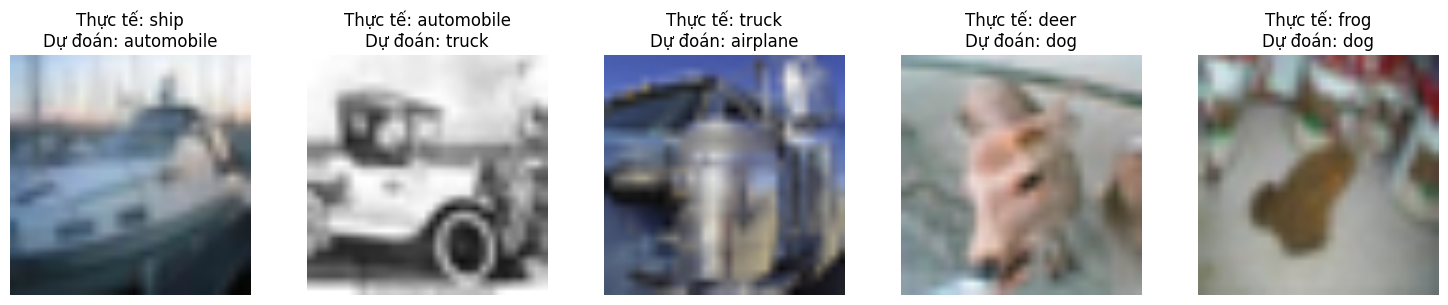

In [11]:
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

model_vit.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(device)
        outputs = model_vit(images_dev)
        _, predicted = torch.max(outputs, 1)
        
        wrong_idx = (predicted != labels.to(device)).nonzero(as_tuple=True)[0]
        
        for idx in wrong_idx:
            misclassified_images.append(images[idx].cpu())
            misclassified_labels.append(labels[idx].item())
            misclassified_preds.append(predicted[idx].item())
            
            if len(misclassified_images) >= 5:
                break
        if len(misclassified_images) >= 5:
            break

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = misclassified_images[i].permute(1, 2, 0).numpy()
    true_label = test_dataset.classes[misclassified_labels[i]]
    pred_label = test_dataset.classes[misclassified_preds[i]]
    
    axes[i].imshow(img)
    axes[i].set_title(f"Thực tế: {true_label}\nDự đoán: {pred_label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()
